# Session 7: Modeling Building



In this final sesion, we will cover two major analytical models: linear regression and logistic regression.
The focus will be on building these models in `sklearn`, evaluating their performance, and experimenting with hyperparameters and variable selection to improve interpretability and predictive power

In [ ]:
#ONLY FOR GOOGLE COLAB

# Code to access drive
from google.colab import drive
drive.mount('/content/drive')

# Set working directory to proper location
import os
os.chdir("/content/drive/MyDrive/Colab Notebooks/Data Analytics/Session 7")

ModuleNotFoundError: No module named 'google.colab'

## Linear Regression

Linear regression is the bread and butter of regression modeling in machine learning. The model assumes a linear relationship between predictors and response variables. For multiple predictors, this relationship can be expressed as:

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \varepsilon$$

Where the model estimates parameters $\beta_0, \beta_1, \beta_2$ to minimize the squared error term $\varepsilon$.

Linear regression is a **parametric model** meaning that it assumes a fixed, inflexible linear relationship between predictors and response. This brings both advantages and challenges:

**Strengths:**
- Highly interpretable coefficients
- Fast training and prediction
- Well-established statistical theory

**Limitations:**  
- Assumes linear relationships (often unrealistic)
- Cannot capture complex, nonlinear patterns
- Performance depends heavily on assumption validity

Let's explore these concepts with practical examples.

### Example 1: When Linear Assumptions Fail

Consider a scenario where the true relationship changes slope after a certain point. After x = 30, the slope of the curve flattens out. Linear regression model will not be able to detect such a change in slope. Linear regression will, however, fit to the data on the assumption of a continuous linear relationship between predictor and response.

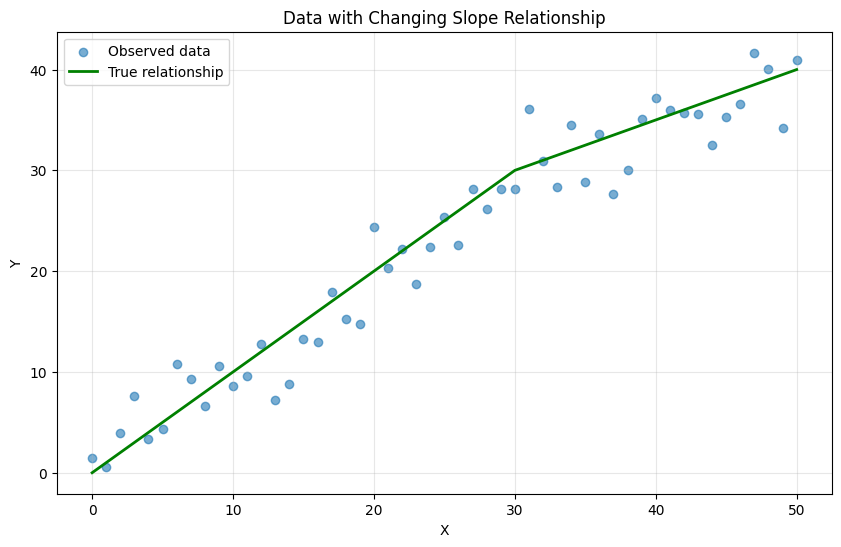

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression, RFE
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# Generate data with changing slope relationship
x = np.arange(0, 51)
# True relationship: linear until x=30, then flatter slope
y_true = np.where(x < 30, x, 30 + 0.5 * (x - 30))
# Add noise
y = y_true + np.random.normal(0, 3, len(x))

# Visualize the data and true relationship
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6, label='Observed data')
plt.plot(x, y_true, 'g-', linewidth=2, label='True relationship')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Data with Changing Slope Relationship')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


The linear regression model clearly results in a misfit here, since it  forces a straight line through data with changing slope. However, on average, the error is not that large. The overall 'acceptable error', easy implementation, and highly interpretable model specification, causes the linear regression model to remain highly popular in many applications.

Linear Regression Results:
Intercept (β₀): 2.47
Slope (β₁): 0.79
R² Score: 0.937
RMSE: 3.032


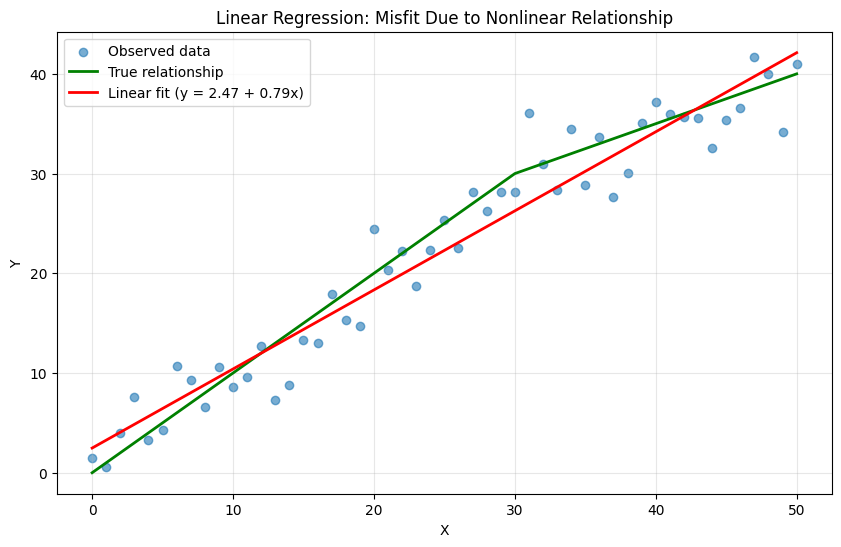

In [2]:
# Fit linear regression model
X = x.reshape(-1, 1)  # sklearn expects 2D array
model = LinearRegression()
model.fit(X, y)

# Make predictions
y_pred = model.predict(X)

# Extract coefficients
intercept = model.intercept_
slope = model.coef_[0]

print(f"Linear Regression Results:")
print(f"Intercept (β₀): {intercept:.2f}")
print(f"Slope (β₁): {slope:.2f}")
print(f"R² Score: {r2_score(y, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y, y_pred)):.3f}")

# Visualize the fit
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6, label='Observed data')
plt.plot(x, y_true, 'g-', linewidth=2, label='True relationship')
plt.plot(x, y_pred, 'r-', linewidth=2, label=f'Linear fit (y = {intercept:.2f} + {slope:.2f}x)')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Linear Regression: Misfit Due to Nonlinear Relationship')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Sklearn vs OLS

**Important Note:** While `sklearn`'s `LinearRegression` and traditional OLS (Ordinary Least Squares) both aim to minimize squared errors, they may use different computational approaches:

- **sklearn**: Uses efficient numerical methods (SVD decomposition) optimized for large datasets
- **OLS**: Uses the classical analytical solution to compute the $\hat{\beta}$'s

For simple linear regression, both should give identical results, but let's verify this by comparing `sklearn` with `statsmodels`, which implements traditional OLS with full statistical inference. One of the main advantages of `statsmodels` is that you can have nice summary of the results of your regression models including  the beta coefficients with standard errors, hypothesis testing, and other model diagnostics. 

In [3]:
# Compare sklearn vs statsmodels OLS
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

print("Comparing sklearn vs Statsmodels OLS")
print("=" * 50)

# sklearn results (already computed)
print(f"sklearn LinearRegression:")
print(f"   Intercept: {intercept:.6f}")
print(f"   Slope: {slope:.6f}")
print(f"   R²: {r2_score(y, y_pred):.6f}")

# Statsmodels OLS: need to add constant for intercept
X_with_constant = sm.add_constant(x)
ols_model = sm.OLS(y, X_with_constant).fit()

print(f"\nStatsmodels OLS:")
print(f"   Intercept: {ols_model.params[0]:.6f}")
print(f"   Slope: {ols_model.params[1]:.6f}") 
print(f"   R²: {ols_model.rsquared:.6f}")

Comparing sklearn vs Statsmodels OLS
sklearn LinearRegression:
   Intercept: 2.474519
   Slope: 0.792903
   R²: 0.936765

Statsmodels OLS:
   Intercept: 2.474519
   Slope: 0.792903
   R²: 0.936765


In [4]:
# Advantage of statsmodels: Full statistical inference
print("Statsmodels Advantage: Beautiful Built-in Summary")
print("=" * 50)

# Display the comprehensive OLS summar
print(ols_model.summary())

Statsmodels Advantage: Beautiful Built-in Summary
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.937
Model:                            OLS   Adj. R-squared:                  0.935
Method:                 Least Squares   F-statistic:                     725.9
Date:                Thu, 13 Nov 2025   Prob (F-statistic):           4.92e-31
Time:                        15:41:14   Log-Likelihood:                -128.94
No. Observations:                  51   AIC:                             261.9
Df Residuals:                      49   BIC:                             265.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
co

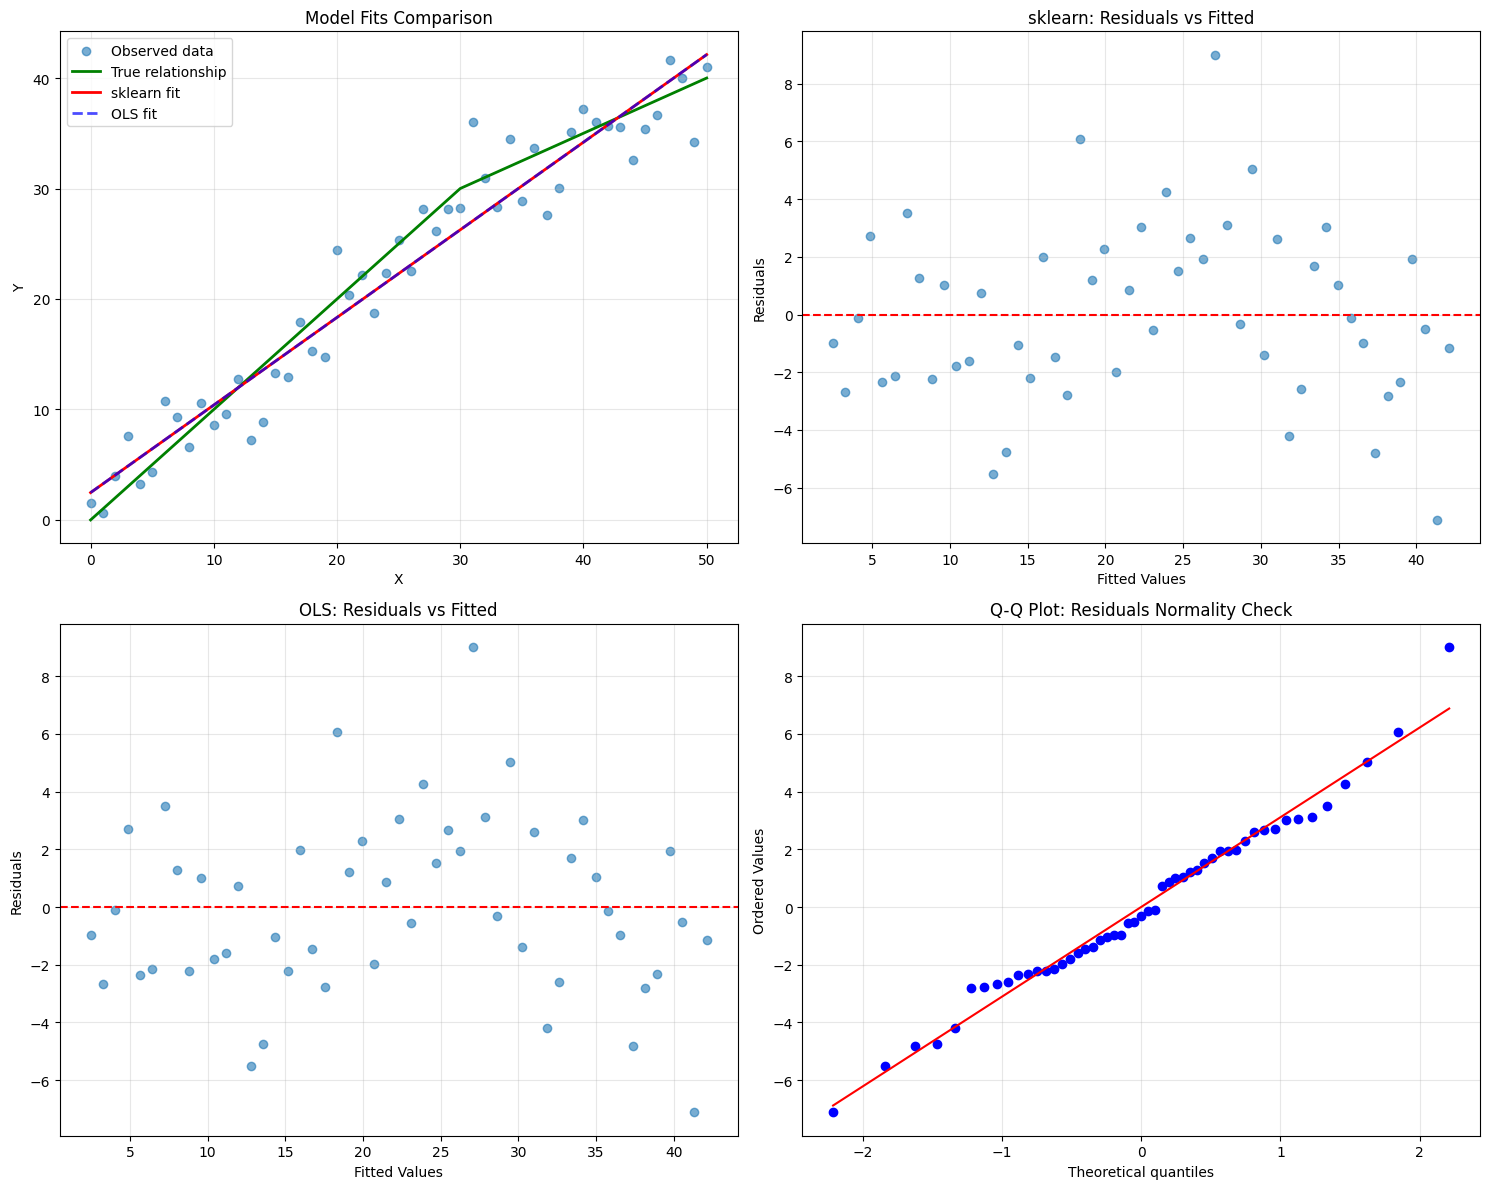

In [5]:
# Visual comparison of fits and residuals
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Both fits (should be identical)
axes[0,0].scatter(x, y, alpha=0.6, label='Observed data')
axes[0,0].plot(x, y_true, 'g-', linewidth=2, label='True relationship')
axes[0,0].plot(x, y_pred, 'r-', linewidth=2, label='sklearn fit')
axes[0,0].plot(x, ols_model.fittedvalues, 'b--', linewidth=2, alpha=0.7, label='OLS fit')
axes[0,0].set_xlabel('X')
axes[0,0].set_ylabel('Y')
axes[0,0].set_title('Model Fits Comparison')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Residuals vs Fitted (sklearn)
sklearn_residuals = y - y_pred
axes[0,1].scatter(y_pred, sklearn_residuals, alpha=0.6)
axes[0,1].axhline(y=0, color='r', linestyle='--')
axes[0,1].set_xlabel('Fitted Values')
axes[0,1].set_ylabel('Residuals')
axes[0,1].set_title('sklearn: Residuals vs Fitted')
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Residuals vs Fitted (OLS)
axes[1,0].scatter(ols_model.fittedvalues, ols_model.resid, alpha=0.6)
axes[1,0].axhline(y=0, color='r', linestyle='--')
axes[1,0].set_xlabel('Fitted Values')
axes[1,0].set_ylabel('Residuals')
axes[1,0].set_title('OLS: Residuals vs Fitted')
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Q-Q plot for normality check
from scipy import stats
stats.probplot(ols_model.resid, dist="norm", plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot: Residuals Normality Check')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



**Key insights:**
- `sklearn` and `statsmodels` OLS produce identical coefficient estimates
- `sklearn` focuses on prediction efficiency (which also explains why the nice statistical output is not available)
- `statsmodels` provides rich statistical inference (p-values, confidence intervals)
- Use `statsmodels` when you need hypothesis testing and model diagnostics
- Use `sklearn` for production ML pipelines and large-scale predictions

### Example 2: Airbnb Demand Prediction

Despite limitations with nonlinear relationships, linear regression remains valuable for real-world applications due to its interpretability and reasonable average performance. 

Let's analyze **Airbnb accommodation data** to predict monthly demand based on factors like price, host status, and location. While these relationships may not be perfectly linear, we can still derive actionable insights.

**Context:** We'll predict monthly demand (0-30 days) using features like price per person, superhost status, and review scores.

Let's first load the dataset and check potential data quality issues. 

In [6]:
# Load the real Airbnb dataset
airbnb = pd.read_csv('./Data/basetable_regression.csv')

# Remove index column (similar to R code)
if airbnb.columns[0] in ['Unnamed: 0', 'index']:
    airbnb = airbnb.drop(airbnb.columns[0], axis=1)
    
print(f"Dataset shape: {airbnb.shape}")
print(f"\nDataset info:")
print(airbnb.info())
print(f"\nFirst few rows:")
airbnb.head()

Dataset shape: (6862, 10)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6862 entries, 0 to 6861
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   host_id               6862 non-null   int64  
 1   accommodates          6862 non-null   int64  
 2   review_scores_rating  5570 non-null   float64
 3   distance              6862 non-null   float64
 4   demand                6862 non-null   float64
 5   entire_home           6862 non-null   int64  
 6   washer_drier          6862 non-null   int64  
 7   superhost             6862 non-null   int64  
 8   response              5993 non-null   float64
 9   price_pp              6862 non-null   float64
dtypes: float64(5), int64(5)
memory usage: 536.2 KB
None

First few rows:


,host_id,accommodates,review_scores_rating,distance,demand,entire_home,washer_drier,superhost,response,price_pp
0,1,3,97.0,4.531863,1.79,1,1,1,86.0,98.333333
1,1,2,95.0,6.973741,1.38,0,1,1,100.0,54.500000
2,1,5,98.0,7.001331,25.80,1,1,0,60.0,67.000000
3,1,2,86.0,5.520051,4.48,0,1,1,83.0,63.500000
4,1,4,97.0,3.995364,1.15,1,0,0,100.0,415.000000


In [7]:
# Data exploration and preprocessing
print("Data Quality Check:")
print(f"Missing values per column:")
print(airbnb.isnull().sum())
print(f"\nBasic statistics:")
airbnb.describe()

Data Quality Check:
Missing values per column:
host_id                    0
accommodates               0
review_scores_rating    1292
distance                   0
demand                     0
entire_home                0
washer_drier               0
superhost                  0
response                 869
price_pp                   0
dtype: int64

Basic statistics:


,host_id,accommodates,review_scores_rating,distance,demand,entire_home,washer_drier,superhost,response,price_pp
count,6862.000000,6862.000000,5570.000000,6862.000000,6862.000000,6862.000000,6862.000000,6862.000000,5993.000000,6862.000000
mean,0.523900,3.212474,95.803052,5.510884,5.029895,0.596328,0.708831,0.415039,96.815618,110.417253
std,0.499465,1.961449,6.923445,2.695458,5.687345,0.490669,0.454334,0.492765,10.795227,110.105514
min,0.000000,1.000000,20.000000,0.232753,0.000000,0.000000,0.000000,0.000000,0.000000,-25.000000
25%,0.000000,2.000000,95.000000,3.406512,0.750000,0.000000,0.000000,0.000000,100.000000,66.616667
50%,1.000000,2.000000,98.000000,5.418188,3.300000,1.000000,1.000000,0.000000,100.000000,92.500000
75%,1.000000,4.000000,100.000000,7.483612,7.420000,1.000000,1.000000,1.000000,100.000000,129.000000
max,1.000000,16.000000,100.000000,12.504076,30.000000,1.000000,1.000000,1.000000,100.000000,4035.000000


In previous lectures, we consistently used `sklearn` to handle missing values. Since we are subsequenlty building a linear regression model, it is better to construct this all in a `Pipeline`, which is more robust. 

**Benefits:**
- **Reproducibility:** Ensures same preprocessing steps for train/test data
- **No data leakage:** Imputer learns parameters only from training data
- **Clean code:** Combines preprocessing + modeling in one streamlined object

**Steps:**
1. `SimpleImputer` Handle missing values with median strategy
2. `LinearRegression`: Fit the linear model

In [8]:
# Prepare data for modeling
X = airbnb.drop('demand', axis=1)
y = airbnb['demand']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 3431 samples, 9 features
Test set: 3431 samples


In [9]:
# Create sklearn pipeline with preprocessing and modeling
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Build the pipeline
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Handle missing values
    ('regressor', LinearRegression())               # Fit linear regression
])

# Fit the pipeline (automatically handles imputation + modeling)
pipeline.fit(X_train, y_train)

# Make predictions
y_pred_train = pipeline.predict(X_train)
y_pred_test = pipeline.predict(X_test)

# Calculate performance metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_r2 = r2_score(y_test, y_pred_test)

print(f"Linear Regression Results:")
print(f"Training RMSE: {train_rmse:.3f} days")
print(f"Test RMSE: {test_rmse:.3f} days")
print(f"Test R² Score: {test_r2:.3f}")

# Compare with baseline (predicting mean demand)
baseline_pred = np.full(len(y_test), y_train.mean())
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
print(f"\nBaseline comparison:")
print(f"Baseline RMSE (always predict mean): {baseline_rmse:.3f} days")
print(f"Improvement over baseline: {((baseline_rmse - test_rmse) / baseline_rmse * 100):.1f}%")


Linear Regression Results:
Training RMSE: 5.603 days
Test RMSE: 5.346 days
Test R² Score: 0.069

Baseline comparison:
Baseline RMSE (always predict mean): 5.542 days
Improvement over baseline: 3.5%


**Key insights:**

- **RMSE:** The test RMSE is 5.346 days. On its own, RMSE is hard to interpret because it depends on the scale of the target variable. Without a baseline, it is unclear whether this represents good performance.  

- **Baseline Comparison:** We compare the model against a simple baseline that always predicts the mean. The baseline RMSE is 5.542 days.  

- **Improvement:** The linear regression model achieves only a **3.5% improvement** over the baseline. This indicates that the model captures **little additional error**, and its predictive power is only slightly better than random guessing.  

- **R² Score:** The low R² of 0.069 confirms that the model explains only a small fraction of the variance in the target variable.

Let's now take a look at the coefficients to get an understanding of our model. 

Model Coefficients (sorted by absolute value):
                Feature  Coefficient  Abs_Coefficient
6             superhost       2.4843           2.4843
4           entire_home       0.9337           0.9337
5          washer_drier      -0.4098           0.4098
0               host_id       0.3834           0.3834
1          accommodates      -0.3314           0.3314
3              distance       0.1564           0.1564
2  review_scores_rating      -0.1066           0.1066
8              price_pp      -0.0028           0.0028
7              response      -0.0016           0.0016

Intercept: 14.5077


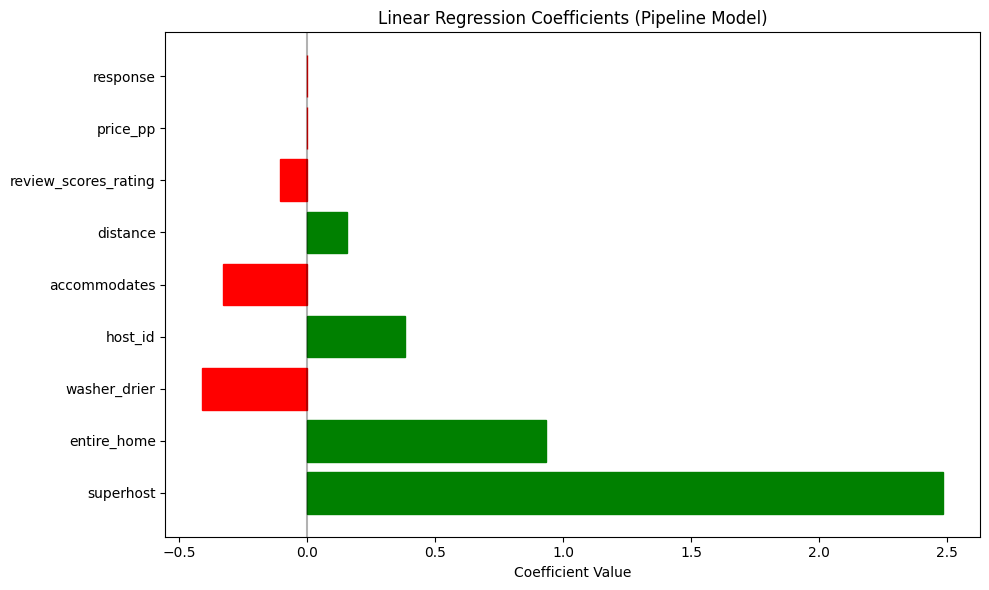

In [10]:
# Analyze model coefficients from the pipeline
feature_names = X_train.columns
lr_model = pipeline.named_steps['regressor']
coefficients = lr_model.coef_
intercept = lr_model.intercept_

# Create coefficient summary
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

print("Model Coefficients (sorted by absolute value):")
print(coef_df.round(4))
print(f"\nIntercept: {intercept:.4f}")

# Visualize coefficients
plt.figure(figsize=(10, 6))
bars = plt.barh(coef_df['Feature'], coef_df['Coefficient'])
# Color bars by sign
for i, bar in enumerate(bars):
    if coef_df['Coefficient'].iloc[i] < 0:
        bar.set_color('red')
    else:
        bar.set_color('green')
        
plt.xlabel('Coefficient Value')
plt.title('Linear Regression Coefficients (Pipeline Model)')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretation**
- **Intercept = 14.5077**: Baseline value of demand when all features are zero. So the baseline demand is 14.5077 days.  
- **superhost = 2.4843**: Being a superhost increases the target by 2.48 days. To be exact, if the the host is a superhost the demand increases by 2.48 days on average while keeping all other features constant. This is the most influential positive factor.

However, one thing is clearly missing in here: no **p-values**! While `sklearn` focuses on prediction, we need `statsmodels` to get p-values and test statistical significance of our coefficients. Let's fit the same model with statsmodels to see which features are statistically significant.

In [11]:
# Get p-values using statsmodels with preprocessed data
import statsmodels.api as sm

# Apply the same preprocessing as the pipeline (imputation)
X_train_imputed = pipeline.named_steps['imputer'].transform(X_train)

# Add constant term for intercept (statsmodels requirement)
X_train_with_const = sm.add_constant(X_train_imputed)

# Fit OLS model for statistical inference
ols_airbnb = sm.OLS(y_train, X_train_with_const).fit()

# Display comprehensive OLS summary with p-values
print("Statistical Significance Results:")
print("=" * 50)
print(ols_airbnb.summary())

Statistical Significance Results:
                            OLS Regression Results                            
Dep. Variable:                 demand   R-squared:                       0.076
Model:                            OLS   Adj. R-squared:                  0.074
Method:                 Least Squares   F-statistic:                     31.30
Date:                Thu, 13 Nov 2025   Prob (F-statistic):           3.63e-53
Time:                        15:41:23   Log-Likelihood:                -10781.
No. Observations:                3431   AIC:                         2.158e+04
Df Residuals:                    3421   BIC:                         2.164e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.5

Clearly, 3 variables are not significant. Since the summary output does not show us the names of the variables, let's brush this up and make a nice plot. 

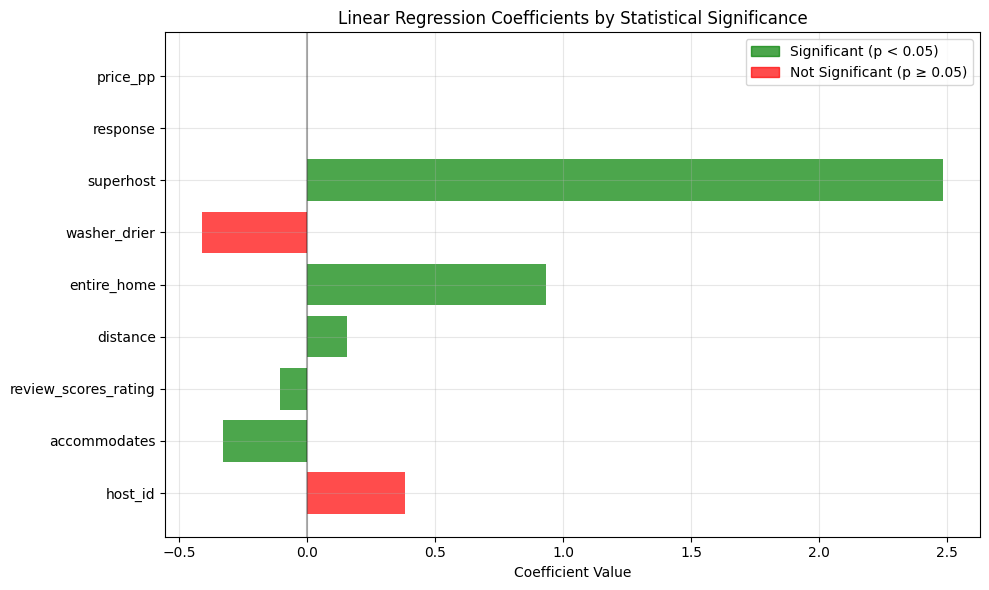


Statistical Significance Summary:
Significant variables (p < 0.05): accommodates, review_scores_rating, distance, entire_home, superhost, price_pp
Non-significant variables (p ≥ 0.05): host_id, washer_drier, response

Only 6 out of 9 variables are statistically significant.


In [12]:
# Visualize coefficient significance
plt.figure(figsize=(10, 6))

# Extract p-values and significance from statsmodels results
coef_stats = pd.DataFrame({
    'Feature': list(feature_names),
    'Coefficient': ols_airbnb.params[1:],  # Skip intercept
    'P_Value': ols_airbnb.pvalues[1:],     # Skip intercept
    'Significant': ols_airbnb.pvalues[1:] < 0.05
})

# Create colors based on significance
colors = ['green' if sig else 'red' for sig in coef_stats['Significant']]

# Plot coefficients with significance indicators
bars = plt.barh(coef_stats['Feature'], coef_stats['Coefficient'], color=colors, alpha=0.7)
plt.xlabel('Coefficient Value')
plt.title('Linear Regression Coefficients by Statistical Significance')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)

# Add legend
import matplotlib.patches as mpatches
green_patch = mpatches.Patch(color='green', alpha=0.7, label='Significant (p < 0.05)')
red_patch = mpatches.Patch(color='red', alpha=0.7, label='Not Significant (p ≥ 0.05)')
plt.legend(handles=[green_patch, red_patch])

plt.tight_layout()
plt.show()

# Summary of significance results
significant_vars = coef_stats[coef_stats['Significant']]['Feature'].tolist()
non_significant_vars = coef_stats[~coef_stats['Significant']]['Feature'].tolist()

print(f"\nStatistical Significance Summary:")
print(f"Significant variables (p < 0.05): {', '.join(significant_vars)}")
print(f"Non-significant variables (p ≥ 0.05): {', '.join(non_significant_vars)}")
print(f"\nOnly {len(significant_vars)} out of {len(coef_stats)} variables are statistically significant.")

The `host_id`, `washer_drier` and `response` are not significant, but they are still included in our model. Especially, `response` is worrisome since the coefficient value is fairly low. Including them just adds additional noise and complexity to our models while not contributing the predictive performance. In the next section, we will therefore explore methods for variable selection and by doing so select the best model. 

## Model and Variable Selection: Selecting The Best Linear Regression Model

Some coefficients correspond to features with minimal predictive power (e.g., `host_id` or `response`), the model may be using noise to make predictions. We'll explore three modern approaches for feature selection in sklearn:

### **Overview of Methods:**

1. **Sequential Feature Selection:** Performance-based stepwise selection using cross-validation
   - Uses `SequentialFeatureSelector` for forward/backward selection
   - Optimizes actual predictive performance, not statistical significance
   - Avoids p-hacking issues of traditional statistical stepwise methods

2. **Regularization (L1/L2/Elastic Net):** Penalty-based feature selection
   - **Ridge (L2)**: Shrinks coefficients but keeps all features
   - **Lasso (L1)**: Can zero out coefficients, performs automatic feature selection
   - **Elastic Net**: Combines L1 and L2 penalties for balanced approach

3. **Importance-weights:** Importance-based feature selection `SelectFromModel`
   - Selects features based on model coefficients or feature importance scores
   - Works with different base estimators
   - Flexible threshold settings for different selection strategies

**Note:** Traditional statistical stepwise selection (based on p-values) suffers from **multiple testing** problems and **p-hacking**, where repeated testing inflates the chance of false positives. The methods below use cross-validation and regularization to avoid these issues while providing robust feature selection.

### Method 1: Sequential Feature Selection

`SequentialFeatureSelector` performs forward/backward selection based on cross-validation performance, not p-values. This avoids p-hacking issues of traditional stepwise methods.

**Key advantages:**
- Uses cross-validation for robust feature evaluation
- Can perform forward, backward, or bidirectional selection
- Optimizes for actual predictive performance (i.e., free to chose your preferred metric)

**Implementation:**
We create a pipeline that combines: 
1) Imputation for missing values
2) Sequential feature selection (selecting 5 features) with 5-fold CV
3) Final linear regression model. This ensures consistent preprocessing and feature selection across train/test data.

In [13]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import cross_val_score

# Create pipeline with sequential selector
# CV inside SequentialFeatureSelector is used for feature selection
# Final evaluation is done on the held-out test set
sfs_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('selector', SequentialFeatureSelector(
        LinearRegression(), 
        n_features_to_select=5,
        direction='forward',
        cv=5,  # This CV is used internally to select best features
        scoring='neg_root_mean_squared_error'
    )),
    ('regressor', LinearRegression())
])

# Fit pipeline on training data (feature selection happens here using internal CV)
sfs_pipeline.fit(X_train, y_train)

,steps,"[('imputer', ...), ('selector', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,estimator,LinearRegression()


In [14]:
# Evaluate the final model on test set
y_pred_sfs = sfs_pipeline.predict(X_test)
rmse_sfs = np.sqrt(mean_squared_error(y_test, y_pred_sfs))

# Get selected features
selected_sfs = X_train.columns[sfs_pipeline.named_steps['selector'].get_support()]
print(f"Sequential Selection Features: {list(selected_sfs)}")
print(f"Sequential Selection Test RMSE: {rmse_sfs:.3f}")
print(f"Number of features: {len(selected_sfs)} out of {len(X_train.columns)} original")

# Optional: Get CV performance during feature selection (on training data only)
cv_scores = cross_val_score(sfs_pipeline, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
print(f"Training CV RMSE: {-cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

Sequential Selection Features: ['accommodates', 'review_scores_rating', 'distance', 'entire_home', 'superhost']
Sequential Selection Test RMSE: 5.359
Number of features: 5 out of 9 original
Training CV RMSE: 5.627 (+/- 0.564)


**Key insights:**
- **Advantage**: You can specify exactly how many features to select, enabling aggressive feature reduction
- **Disadvantage**: You must pre-specify the number of features (`n_features_to_select=5`)
- **To find optimal K**: You'd need another cross-validation loop to select the best number of features, making it computationally expensive

**Alternative**: Regularization methods (Lasso, Elastic Net) automatically determine the optimal number of features without requiring you to specify K in advance. 

### Method 2: Regularization (L1/L2/Elastic Net)

Regularization adds penalty terms to prevent overfitting and automatically performs feature selection:
- **Ridge (L2)**: Shrinks coefficients but keeps all features
- **Lasso (L1)**: Can zero out coefficients, performs automatic feature selection  
- **Elastic Net**: Combines L1 and L2 penalties for balanced approach

**Alpha (α) Hyperparameter:**
- In `sklearn`, the regularization strength is controlled by the `alpha` parameter (equivalent to λ in mathematical notation)
- **Higher α**: Stronger regularization → smaller coefficients → simpler model
- **Lower α**: Weaker regularization → larger coefficients → more complex model
- **α = 0**: No regularization (equivalent to ordinary linear regression)

**Implementation:**
We'll create separate pipelines for each regularization method. Each pipeline:
1. **Preprocessing**: Handle missing values with median imputation
2. **Hyperparameter Tuning**: Use GridSearchCV with 5-fold CV to find optimal α (and l1_ratio for Elastic Net)
3. **Final Evaluation**: Test the best model on held-out test set

In [15]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# Define alpha range for hyperparameter tuning (reduced for computational efficiency)
alpha_range = [0.1, 1.0, 10.0] 
print(f"Alpha range: {alpha_range} (reduced for computational efficiency)")

print("\nRIDGE REGRESSION (L2 Regularization)")
print("-" * 40)

ridge_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('regressor', Ridge())
])

ridge_params = {'regressor__alpha': alpha_range}
ridge_grid = GridSearchCV(
    ridge_pipeline, 
    ridge_params, 
    cv=5, 
    scoring='neg_root_mean_squared_error',
    return_train_score=True
)
ridge_grid.fit(X_train, y_train)

# Evaluate on test set
y_pred_ridge = ridge_grid.predict(X_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print(f"Best α (alpha): {ridge_grid.best_params_['regressor__alpha']}")
print(f"CV RMSE: {-ridge_grid.best_score_:.3f}")
print(f"Test RMSE: {rmse_ridge:.3f}")
print(f"Features retained: {len(X_train.columns)} (Ridge keeps all features)")

Alpha range: [0.1, 1.0, 10.0] (reduced for computational efficiency)

RIDGE REGRESSION (L2 Regularization)
----------------------------------------
Best α (alpha): 10.0
CV RMSE: 5.621
Test RMSE: 5.346
Features retained: 9 (Ridge keeps all features)


In [16]:
print("\nLASSO REGRESSION (L1 Regularization)")
print("-" * 40)

lasso_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('regressor', Lasso(max_iter=2000))
])

lasso_params = {'regressor__alpha': alpha_range}  # Same reduced range as Ridge
lasso_grid = GridSearchCV(
    lasso_pipeline, 
    lasso_params, 
    cv=5, 
    scoring='neg_root_mean_squared_error',
    return_train_score=True
)
lasso_grid.fit(X_train, y_train)

# Evaluate on test set
y_pred_lasso = lasso_grid.predict(X_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

# Check feature selection (non-zero coefficients)
lasso_coefs = lasso_grid.best_estimator_.named_steps['regressor'].coef_
selected_lasso = X_train.columns[lasso_coefs != 0]

print(f"Best α (alpha): {lasso_grid.best_params_['regressor__alpha']}")
print(f"CV RMSE: {-lasso_grid.best_score_:.3f}")
print(f"Test RMSE: {rmse_lasso:.3f}")
print(f"Features selected: {len(selected_lasso)} out of {len(X_train.columns)}")
print(f"Selected features: {list(selected_lasso)}")


LASSO REGRESSION (L1 Regularization)
----------------------------------------
Best α (alpha): 0.1
CV RMSE: 5.635
Test RMSE: 5.369
Features selected: 7 out of 9
Selected features: ['host_id', 'accommodates', 'review_scores_rating', 'distance', 'entire_home', 'superhost', 'price_pp']


**Elastic Net: Additional Hyperparameter (l1_ratio):**
- Elastic Net requires tuning **two hyperparameters**: `alpha` and `l1_ratio`
- **l1_ratio**: Controls the balance between L1 and L2 penalties
  - `l1_ratio = 0`: Pure Ridge regression (L2 only)
  - `l1_ratio = 1`: Pure Lasso regression (L1 only)  
  - `l1_ratio = 0.5`:£ Equal mix of L1 and L2 penalties
- This **doubles the computational burden** as we need to search over both parameters

In [17]:
print("\nELASTIC NET (L1 + L2 Regularization)")
print("-" * 40)

elastic_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('regressor', ElasticNet(max_iter=2000))
])

# Grid search over both alpha and l1_ratio
elastic_params = {
    'regressor__alpha': [0.1, 1.0, 10.0], 
    'regressor__l1_ratio': [0.1, 0.5, 0.9]  # 0.1=mostly L2, 0.9=mostly L1
}
elastic_grid = GridSearchCV(
    elastic_pipeline, 
    elastic_params, 
    cv=5, 
    scoring='neg_root_mean_squared_error',
    return_train_score=True
)
elastic_grid.fit(X_train, y_train)

# Evaluate on test set
y_pred_elastic = elastic_grid.predict(X_test)
rmse_elastic = np.sqrt(mean_squared_error(y_test, y_pred_elastic))

# Check feature selection
elastic_coefs = elastic_grid.best_estimator_.named_steps['regressor'].coef_
selected_elastic = X_train.columns[elastic_coefs != 0]

print(f"Best α (alpha): {elastic_grid.best_params_['regressor__alpha']}")
print(f"Best l1_ratio: {elastic_grid.best_params_['regressor__l1_ratio']}")
print(f"CV RMSE: {-elastic_grid.best_score_:.3f}")
print(f"Test RMSE: {rmse_elastic:.3f}")
print(f"Features selected: {len(selected_elastic)} out of {len(X_train.columns)}")
print(f"Selected features: {list(selected_elastic)}")


ELASTIC NET (L1 + L2 Regularization)
----------------------------------------
Best α (alpha): 0.1
Best l1_ratio: 0.1
CV RMSE: 5.632
Test RMSE: 5.357
Features selected: 9 out of 9
Selected features: ['host_id', 'accommodates', 'review_scores_rating', 'distance', 'entire_home', 'washer_drier', 'superhost', 'response', 'price_pp']


**Coefficient Path Analysis:**
We'll also visualize how coefficients change across different α values to understand the regularization effect.

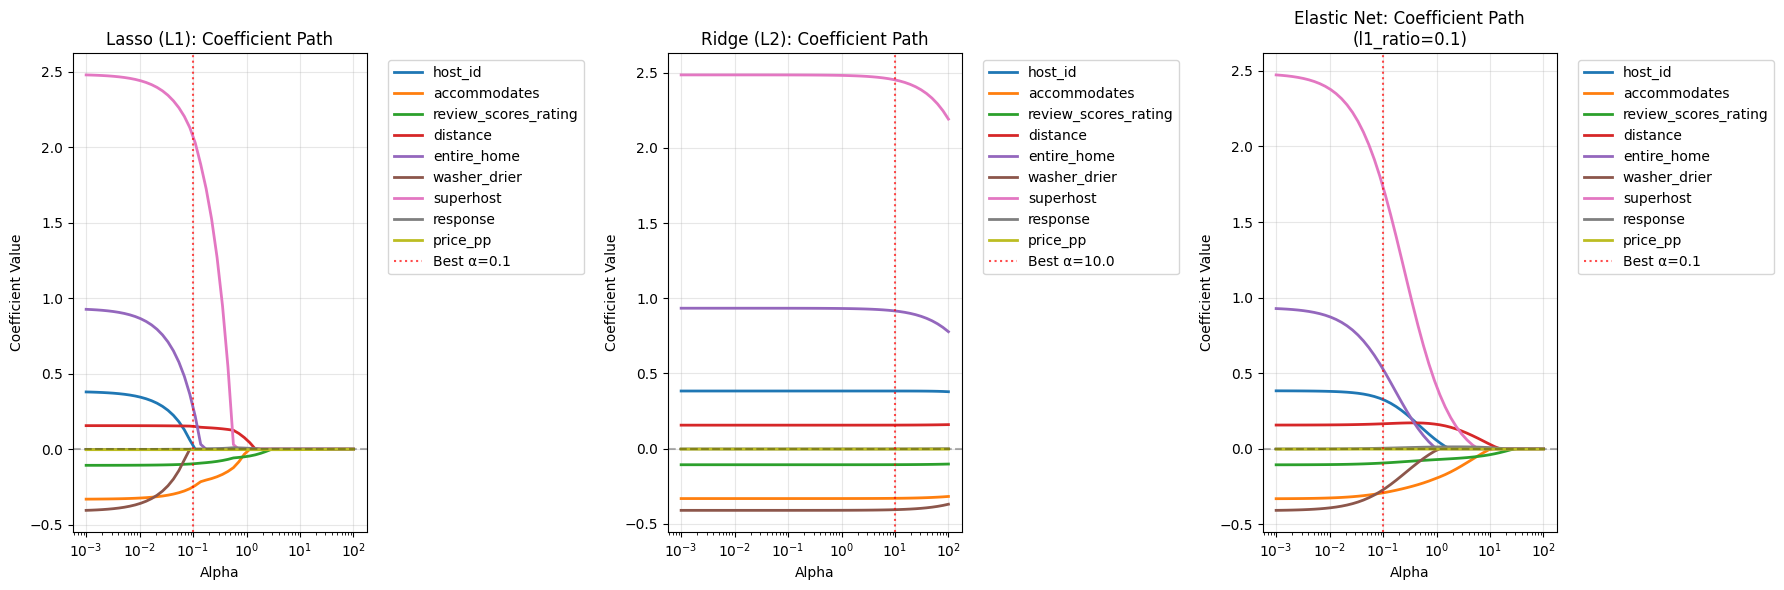

In [18]:
# Visualize Coefficient Paths: How coefficients change with alpha
# Prepare data for coefficient path analysis
X_train_imputed = Pipeline([('imputer', SimpleImputer(strategy='median'))]).fit_transform(X_train)

# Define a wider range of alpha values for smooth coefficient paths
alphas_path = np.logspace(-3, 2, 50)  # From 0.001 to 100

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# =============================================================================
# LASSO COEFFICIENT PATH  
# =============================================================================
# Lasso coefficient path
lasso_coefs_path = []
for alpha in alphas_path:
    lasso_model = Lasso(alpha=alpha, max_iter=2000)
    lasso_model.fit(X_train_imputed, y_train)
    lasso_coefs_path.append(lasso_model.coef_)

lasso_coefs_path = np.array(lasso_coefs_path)

# Plot Lasso path
for i, feature in enumerate(X_train.columns):
    axes[0].plot(alphas_path, lasso_coefs_path[:, i], label=feature, linewidth=2)
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha')
axes[0].set_ylabel('Coefficient Value')
axes[0].set_title('Lasso (L1): Coefficient Path')
axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[0].axvline(x=lasso_grid.best_params_['regressor__alpha'], color='red', 
                linestyle=':', alpha=0.7, label=f"Best α={lasso_grid.best_params_['regressor__alpha']}")
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, alpha=0.3)

# =============================================================================
# RIDGE COEFFICIENT PATH  
# =============================================================================
ridge_coefs_path = []
for alpha in alphas_path:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train_imputed, y_train)
    ridge_coefs_path.append(ridge_model.coef_)

ridge_coefs_path = np.array(ridge_coefs_path)

# Plot Ridge path
for i, feature in enumerate(X_train.columns):
    axes[1].plot(alphas_path, ridge_coefs_path[:, i], label=feature, linewidth=2)
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha')
axes[1].set_ylabel('Coefficient Value')
axes[1].set_title('Ridge (L2): Coefficient Path')
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[1].axvline(x=ridge_grid.best_params_['regressor__alpha'], color='red', 
                linestyle=':', alpha=0.7, label=f"Best α={ridge_grid.best_params_['regressor__alpha']}")
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, alpha=0.3)

# =============================================================================
# ELASTIC NET COEFFICIENT PATH
# =============================================================================
elastic_coefs_path = []
best_l1_ratio = elastic_grid.best_params_['regressor__l1_ratio']

for alpha in alphas_path:
    elastic_model = ElasticNet(alpha=alpha, l1_ratio=best_l1_ratio, max_iter=2000)
    elastic_model.fit(X_train_imputed, y_train)
    elastic_coefs_path.append(elastic_model.coef_)

elastic_coefs_path = np.array(elastic_coefs_path)

# Plot Elastic Net path
for i, feature in enumerate(X_train.columns):
    axes[2].plot(alphas_path, elastic_coefs_path[:, i], label=feature, linewidth=2)
axes[2].set_xscale('log')
axes[2].set_xlabel('Alpha')
axes[2].set_ylabel('Coefficient Value')
axes[2].set_title(f'Elastic Net: Coefficient Path\n(l1_ratio={best_l1_ratio})')
axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[2].axvline(x=elastic_grid.best_params_['regressor__alpha'], color='red', 
                linestyle=':', alpha=0.7, label=f"Best α={elastic_grid.best_params_['regressor__alpha']}")
axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**Key insights:**
- **Red vertical line:** Optimal **α** selected by cross-validation  
- **Higher α:** Stronger regularization --> smaller coefficients (with L1 and Elastic Net even 0)
- **Lasso (L1):** Coefficients can shrink to exactly zero --> automatic feature selection. You can clearly see `washer_drier` and `response` are are zero with the current alpha. It is also lear that with slightly higher values of alpha other variables like `entire_home` would also become 0. 
- **Ridge (L2):** Coefficients shrink toward zero but do not reach zero --> all features retained  
- **Elastic Net:** Combines both behaviors --> balanced feature selection and shrinkage. Alpha is currently too small to shrink variables towards zero but with higher values variables like `host_id` and `response` also become 0. 


### Method 3: Importance-based Feature Selection

`SelectFromModel` selects features based on importance weights from fitted estimators. This is a general purpose procedure that works with any estimator providing `feature_importances_` or `coef_` attributes. Hence, it uses the magnitude of model coefficients or feature importance scores to rank features
and sets a threshold to select the most important features. 

**Threshold Options:**
- `'median'`: Select features with importance above the median
- `'mean'`: Select features with importance above the mean  (default)
- **Custom value**: Set specific threshold (e.g., `threshold=0.1`)
- `'1.25*mean'`: Select features above 125% of mean importance

**Base Estimators:**
For linear regression contexts, we'll use two complementary base estimators:
1. **Linear Regression**: Uses coefficient magnitude (similar to statistical significance approach but without p-values)
2. **Lasso Regression**: Uses regularized coefficients (automatically handles feature selection through L1 penalty)

**Implementation Strategy:**
Each pipeline combines:
1. **Preprocessing**: Handle missing values with median imputation
2. **Feature Selection**: Use SelectFromModel with Linear Regression or Lasso as base estimator
3. **Final Model**: Fit linear regression on the selected features

In [19]:
from sklearn.feature_selection import SelectFromModel

# =============================================================================
# 1. SELECTFROMMODEL WITH LINEAR REGRESSION
# =============================================================================
print("\nLinear Regression (Coefficient Magnitude)")
print("-" * 40)

sfm_linear_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('selector', SelectFromModel(LinearRegression(), threshold='median')),
    ('regressor', LinearRegression())
])

sfm_linear_pipeline.fit(X_train, y_train)
y_pred_sfm_linear = sfm_linear_pipeline.predict(X_test)
rmse_sfm_linear = np.sqrt(mean_squared_error(y_test, y_pred_sfm_linear))

# Get selected features and coefficient magnitudes
selector = sfm_linear_pipeline.named_steps['selector']
selected_sfm_linear = X_train.columns[selector.get_support()]
feature_importance_linear = np.abs(selector.estimator_.coef_)

print(f"Threshold strategy: median coefficient magnitude")
print(f"Threshold value: {selector.threshold_:.4f}")
print(f"Features selected: {len(selected_sfm_linear)} out of {len(X_train.columns)}")
print(f"Selected features: {list(selected_sfm_linear)}")
print(f"Test RMSE: {rmse_sfm_linear:.3f}")

# =============================================================================
# 2. SELECTFROMMODEL WITH LASSO REGRESSION  
# =============================================================================
print("\nLasso Regression (Regularized Coefficients)")
print("-" * 40)

sfm_lasso_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('selector', SelectFromModel(Lasso(alpha=1.0, max_iter=2000), threshold='median')),
    ('regressor', LinearRegression())
])

sfm_lasso_pipeline.fit(X_train, y_train)
y_pred_sfm_lasso = sfm_lasso_pipeline.predict(X_test)
rmse_sfm_lasso = np.sqrt(mean_squared_error(y_test, y_pred_sfm_lasso))

# Get selected features and Lasso coefficients
selector_lasso = sfm_lasso_pipeline.named_steps['selector']
selected_sfm_lasso = X_train.columns[selector_lasso.get_support()]
lasso_coefs = selector_lasso.estimator_.coef_

print(f"\nLasso alpha: 1.0 (fixed regularization)")
print(f"Threshold strategy: median absolute coefficient")
print(f"Threshold value: {selector_lasso.threshold_:.4f}")
print(f"Features selected: {len(selected_sfm_lasso)} out of {len(X_train.columns)}")
print(f"Selected features: {list(selected_sfm_lasso)}")
print(f"Test RMSE: {rmse_sfm_lasso:.3f}")


Linear Regression (Coefficient Magnitude)
----------------------------------------
Threshold strategy: median coefficient magnitude
Threshold value: 0.3314
Features selected: 5 out of 9
Selected features: ['host_id', 'accommodates', 'entire_home', 'washer_drier', 'superhost']
Test RMSE: 5.377

Lasso Regression (Regularized Coefficients)
----------------------------------------

Lasso alpha: 1.0 (fixed regularization)
Threshold strategy: median absolute coefficient
Threshold value: 0.0028
Features selected: 5 out of 9
Selected features: ['accommodates', 'review_scores_rating', 'distance', 'response', 'price_pp']
Test RMSE: 5.476


**Key insights:**
- Different base estimators can select different features  
- Linear regression uses coefficient magnitude for feature importance  
- Lasso adds regularization which can shrink coefficients to zero  
- Threshold strategy affects number of selected features  
- The `'median'` threshold typically selects about 50% of features

In [20]:
# Compare all feature selection methods
print("\n" + "="*80)
print("FEATURE SELECTION COMPARISON")
print("="*80)
print(f"Baseline: Original Model RMSE = {test_rmse:.3f} (using all {len(X_train.columns)} features)")
print("="*80)

methods_data = {
    'Method': ['Original Model', 'Sequential Selection', 'Ridge (L2)', 'Lasso (L1)', 'Elastic Net', 
               'SelectFromModel (Linear)', 'SelectFromModel (Lasso)'],
    'Test RMSE': [test_rmse, rmse_sfs, 
             rmse_ridge, rmse_lasso, rmse_elastic,
             rmse_sfm_linear, rmse_sfm_lasso],
    'Features': [len(X_train.columns), len(selected_sfs), len(X_train.columns), 
                len(selected_lasso), len(selected_elastic), 
                len(selected_sfm_linear), len(selected_sfm_lasso)],
    'Feature Reduction (%)': [0, 
                             round((1 - len(selected_sfs)/len(X_train.columns)) * 100, 1),
                             0,
                             round((1 - len(selected_lasso)/len(X_train.columns)) * 100, 1),
                             round((1 - len(selected_elastic)/len(X_train.columns)) * 100, 1),
                             round((1 - len(selected_sfm_linear)/len(X_train.columns)) * 100, 1),
                             round((1 - len(selected_sfm_lasso)/len(X_train.columns)) * 100, 1)]
}

comparison_df = pd.DataFrame(methods_data)
comparison_df['Test RMSE'] = comparison_df['Test RMSE'].round(3)

# Calculate RMSE improvement over original model
original_rmse = test_rmse
comparison_df['RMSE Improvement (%)'] = round(((original_rmse - comparison_df['Test RMSE']) / original_rmse * 100), 1)

print(comparison_df.to_string(index=False))


FEATURE SELECTION COMPARISON
Baseline: Original Model RMSE = 5.346 (using all 9 features)
                  Method  Test RMSE  Features  Feature Reduction (%)  RMSE Improvement (%)
          Original Model      5.346         9                    0.0                  -0.0
    Sequential Selection      5.359         5                   44.4                  -0.2
              Ridge (L2)      5.346         9                    0.0                  -0.0
              Lasso (L1)      5.369         7                   22.2                  -0.4
             Elastic Net      5.357         9                    0.0                  -0.2
SelectFromModel (Linear)      5.377         5                   44.4                  -0.6
 SelectFromModel (Lasso)      5.476         5                   44.4                  -2.4


**Key insights:**
- Original model has the best performance.   
- Best feature selection achieves no improvement in RMSE. 
- Feature selection can reduce complexity by up to 44% with minimal performance loss  (Sequentuial selection)
- Regularization methods provide a good balance between performance and feature reduction. 

In this case, there were not enough features for feature selection to have a strong effect. When models perform similarly, the most compact model should be preferred for simplicity and interpretability. More extensive cross-validation might be needed to identify the most stable feature subset and show more clear improvements.  

## Logistic Regression

Logistic regression is a natural extension of linear regression for **classification problems**. While linear regression predicts continuous values, logistic regression predicts **probabilities** between 0 and 1, making it ideal for binary outcomes like churn/no churn, spam/not spam, or success/failure. In short, logistic regression does this by using the sigmoid/logistic function to transform real numbers to probabilities between 0 and 1. y

 Since logistic regression uses the same linear combination of features as linear regression, **all the techniques we learned for linear regression directly apply**:

1. **Feature Selection Methods:**
   - Sequential feature selection
   - Regularization (Ridge, Lasso, Elastic Net)  
   - Importance-based selection

2. **Regularization Benefits:**
   - **Ridge (L2):** Prevents overfitting, keeps all features
   - **Lasso (L1):** Automatic feature selection, sparse models
   - **Elastic Net:** Balanced approach for correlated features

3. **Model Evaluation:**
   - Cross-validation for hyperparameter tuning
   - Pipeline approach for preprocessing
   - Coefficient interpretation for model understanding

The main difference is that we use **classification metrics** (AUC, accuracy, precision/recall) instead of regression metrics (RMSE, R²).

Let's demonstrate this by applying regularized logistic regression to the **churn** prediction problem of the previous lecture, using the same systematic approach as we used for linear regression.

### Data Preparation and Baseline

Let's start by loading the churn dataset from the original R file (`basetable.csv`) and preparing it for logistic regression. This dataset contains the same churn prediction variables used in the R example, with the `churn` variable already properly encoded as 0/1. We'll mainly use the same pipeline approach as in linear regression to ensure consistent preprocessing. 

 **Difference with the previous set-up**: Since our dataset is sufficiently large, we will use a 70/30 train-test split. This ensures that the training set is large enough to provide robust learning and stable results during cross-validation, while the test set still contains enough data to give a reliable estimate of out-of-sample performance. By keeping more data for training, we also guarantee that each fold in the cross-validation loop includes enough samples for consistent and meaningful model evaluation.

In [21]:
# Import additional libraries for logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, precision_recall_curve

# Load the churn dataset
basetable = pd.read_csv('./Data/basetable.csv')

print(f"Dataset shape: {basetable.shape}")
print(f"Churn distribution:")
print(basetable['churn'].value_counts())
print(f"Churn rate: {basetable['churn'].mean():.3f}")

# Display first few rows
basetable.head()

Dataset shape: (41739, 5)
Churn distribution:
churn
0    40166
1     1573
Name: count, dtype: int64
Churn rate: 0.038


,Monetary_score,Total_quantity,recency_score,days_customer,churn
0,12519.0,715,16,15503,0
1,7315.2,309,36,16964,0
2,3267.8,176,15,22442,0
3,1289.0,74,21,16598,0
4,6789.0,390,1,15137,0


In [22]:
# Prepare data for modeling
X = basetable.drop('churn', axis=1)
y = basetable['churn']

# Simple train/test split. 
# Hyperparameter tuning will use 5-fold CV within GridSearchCV
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Dataset splits:")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print(f"\nClass distribution in splits:")
print(f"Train: {y_train.value_counts().to_dict()}")
print(f"Test: {y_test.value_counts().to_dict()}")

Dataset splits:
Training set: 29217 samples
Test set: 12522 samples

Class distribution in splits:
Train: {0: 28116, 1: 1101}
Test: {0: 12050, 1: 472}


### Ridge Logistic Regression (L2 Regularization)

We'll start with Ridge logistic regression, which adds an L2 penalty term to prevent overfitting.

**Parameters:**
- **C (Inverse of α):** In `sklearn`, `C` is the inverse of regularization strength parameter Lambda from the theory. Lower C = stronger regularization?
- **solver:** Algorithm for optimization. `liblinear` works well for small datasets, `lbfgs' for larger ones

Let's fit a Ridge logistic regression and examine the coefficient path as regularization strength varies.

In [23]:
# Ridge Logistic Regression with GridSearchCV
from sklearn.preprocessing import StandardScaler

print("RIDGE LOGISTIC REGRESSION - HYPERPARAMETER TUNING")
print("=" * 55)

# Create Ridge logistic regression pipeline (same pattern as linear regression)
ridge_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),  # Important for regularized models
    ('classifier', LogisticRegression(penalty='l2', solver='liblinear', random_state=42, max_iter=2000))
])

# Define parameter grid - broader range for Ridge
ridge_param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]  # Broad grid for L2
}

# GridSearchCV with 5-fold cross-validation
ridge_grid = GridSearchCV(
    ridge_pipeline,
    ridge_param_grid,
    cv=5,
    scoring='roc_auc',  # Use AUC for classification
    return_train_score=True,
    n_jobs=-1
)

# Fit on training data
ridge_grid.fit(X_train, y_train)

# Evaluate on test set
y_pred_ridge = ridge_grid.predict(X_test) #for accuracy
y_pred_proba_ridge = ridge_grid.predict_proba(X_test)[:, 1]
test_auc_ridge = roc_auc_score(y_test, y_pred_proba_ridge)
test_accuracy_ridge = accuracy_score(y_test, y_pred_ridge)

print(f"Best parameters: {ridge_grid.best_params_}")
print(f"Best CV AUC: {ridge_grid.best_score_:.4f}")
print(f"Test AUC: {test_auc_ridge:.4f}")
print(f"Test Accuracy: {test_accuracy_ridge:.4f}")

# Get the best Ridge coefficients
best_ridge_coefs = ridge_grid.best_estimator_.named_steps['classifier'].coef_[0]
feature_names = X_train.columns
ridge_coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': best_ridge_coefs,
    'Abs_Coefficient': np.abs(best_ridge_coefs)
}).sort_values('Abs_Coefficient', ascending=False)

print(f"\nRidge Coefficients (C = {ridge_grid.best_params_['classifier__C']}):")
print(ridge_coef_df.round(4))
print(f"Features retained: {len(feature_names)} (Ridge keeps all features)")

RIDGE LOGISTIC REGRESSION - HYPERPARAMETER TUNING


Best parameters: {'classifier__C': 1000.0}
Best CV AUC: 0.7877
Test AUC: 0.7629
Test Accuracy: 0.9625

Ridge Coefficients (C = 1000.0):
          Feature  Coefficient  Abs_Coefficient
0  Monetary_score     -11.9552          11.9552
2   recency_score       0.4580           0.4580
3   days_customer      -0.3965           0.3965
1  Total_quantity       0.1763           0.1763
Features retained: 4 (Ridge keeps all features)


One feature is clearly very important (`Monetary_score`),  as it has the highest absolute value of the coefficient.

Let's have a look at the coefficient path as well, which shows how coefficients change across different C values (regularization strengths). 

Computing Ridge coefficient path for visualization...


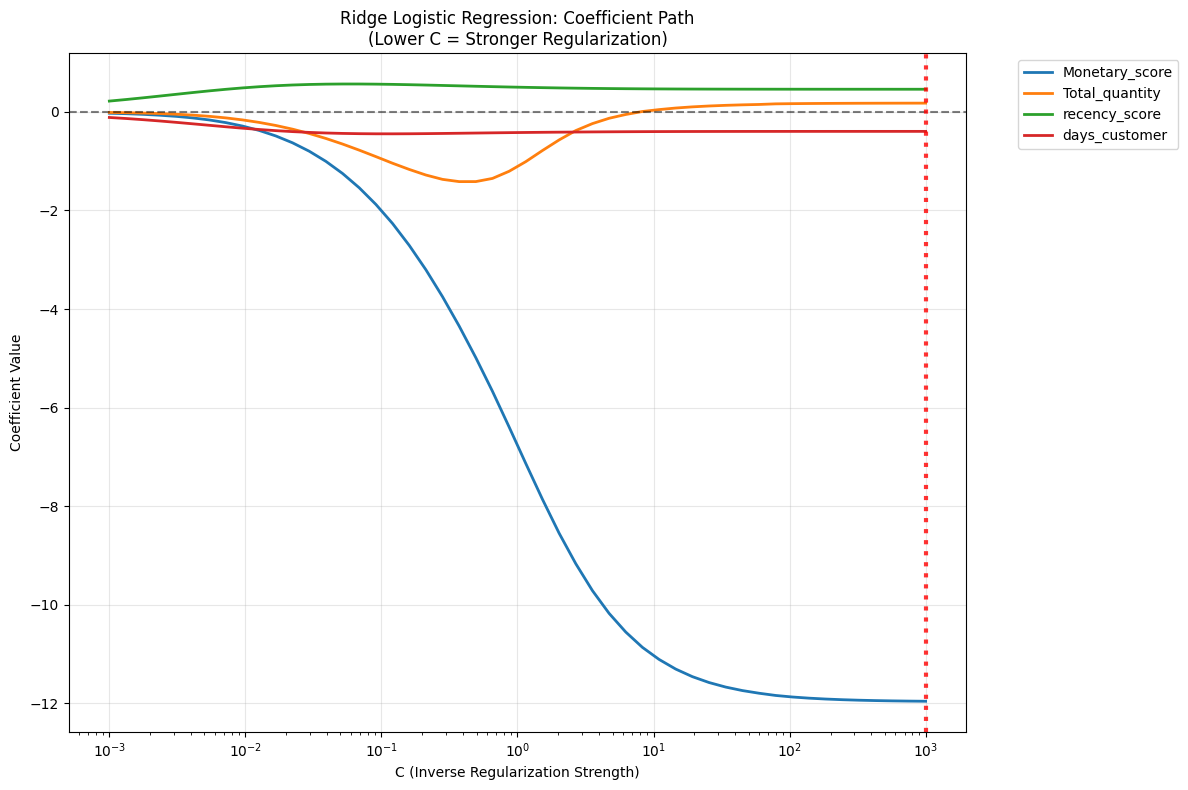

In [24]:
# Visualize Logistic Regression Coefficient Path

# Define a range of C values for Ridge path visualization
C_values = np.logspace(-3, 3, 50)  # From 0.001 to 1000

# Prepare data with scaling and imputation (same as pipeline)
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_train_processed = scaler.fit_transform(imputer.fit_transform(X_train))

# Store coefficients for Ridge path visualization
ridge_coefficients = []

print("Computing Ridge coefficient path for visualization...")

# Ridge coefficient path - compute for visualization
for C in C_values:
    ridge_lr = LogisticRegression(
        penalty='l2', 
        C=C, 
        solver='liblinear',
        random_state=42,
        max_iter=2000
    )
    ridge_lr.fit(X_train_processed, y_train)
    ridge_coefficients.append(ridge_lr.coef_[0])

ridge_coefficients = np.array(ridge_coefficients)

# Plot Ridge coefficient path
plt.figure(figsize=(12, 8))

# Ridge coefficient path
for i, feature in enumerate(X_train.columns):
    plt.plot(C_values, ridge_coefficients[:, i], label=feature, linewidth=2)

plt.xscale('log')
plt.xlabel('C (Inverse Regularization Strength)')
plt.ylabel('Coefficient Value')
plt.title('Ridge Logistic Regression: Coefficient Path\n(Lower C = Stronger Regularization)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.axvline(x=ridge_grid.best_params_['classifier__C'], color='red', 
            linestyle=':', linewidth=3, alpha=0.8, label=f"Best C={ridge_grid.best_params_['classifier__C']}")
plt.tight_layout()
plt.show()

**Key insights:**

- As C decreases (stronger regularization), coefficients shrink toward zero.
- Ridge coefficients shrink but never reach exactly zero.
- Red vertical line shows optimal C selected by cross-validation
- `Recency_score` comes out as the most important variable since it retains a reasonable coefficient value even after high regularization. 

### Lasso Logistic Regression 

Lasso logistic regression is very similar to Ridge, using the same pipeline approach and hyperparameter tuning process. The main difference is that Lasso uses L1 regularization instead of L2, which can drive coefficients to exactly zero, providing automatic feature selection.

**Implementation**
- **Same Parameters:** Uses the same C parameter (inverse regularization strength)
- **Same Pipeline:** Identical preprocessing and evaluation approach

Let's apply the same systematic approach as Ridge to see which features Lasso selects.


In [25]:
# Lasso Logistic Regression
print("LASSO LOGISTIC REGRESSION - HYPERPARAMETER TUNING")
print("=" * 55)

# Create Lasso logistic regression pipeline
lasso_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(penalty='l1', solver='liblinear', random_state=42, max_iter=2000))
])

# Same broad parameter grid as Ridge
lasso_param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
}

# GridSearchCV with 5-fold cross-validation
lasso_grid = GridSearchCV(
    lasso_pipeline,
    lasso_param_grid,
    cv=5,
    scoring='roc_auc',
    return_train_score=True,
    n_jobs=-1
)

# Fit on training data
lasso_grid.fit(X_train, y_train)

# Evaluate on test set
y_pred_lasso = lasso_grid.predict(X_test)
y_pred_proba_lasso = lasso_grid.predict_proba(X_test)[:, 1]
test_auc_lasso = roc_auc_score(y_test, y_pred_proba_lasso)
test_accuracy_lasso = accuracy_score(y_test, y_pred_lasso)

print(f"Best parameters: {lasso_grid.best_params_}")
print(f"Best CV AUC: {lasso_grid.best_score_:.4f}")
print(f"Test AUC: {test_auc_lasso:.4f}")
print(f"Test Accuracy: {test_accuracy_lasso:.4f}")

# Get the best Lasso coefficients and feature selection
best_lasso_coefs = lasso_grid.best_estimator_.named_steps['classifier'].coef_[0]
selected_features_lasso = X_train.columns[best_lasso_coefs != 0]
lasso_coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_lasso_coefs,
    'Selected': best_lasso_coefs != 0
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"\nLasso Feature Selection (C = {lasso_grid.best_params_['classifier__C']}):")
print(f"Selected {len(selected_features_lasso)} out of {len(X_train.columns)} features")
print(f"Selected features: {list(selected_features_lasso)}")
print(f"\nLasso Coefficients:")
print(lasso_coef_df.round(4))

LASSO LOGISTIC REGRESSION - HYPERPARAMETER TUNING
Best parameters: {'classifier__C': 1000.0}
Best CV AUC: 0.7877
Test AUC: 0.7629
Test Accuracy: 0.9625

Lasso Feature Selection (C = 1000.0):
Selected 4 out of 4 features
Selected features: ['Monetary_score', 'Total_quantity', 'recency_score', 'days_customer']

Lasso Coefficients:
          Feature  Coefficient  Selected
0  Monetary_score     -11.9559      True
2   recency_score       0.4579      True
3   days_customer      -0.3964      True
1  Total_quantity       0.1717      True


Let's have a look at the coefficient path as well. 

Computing Lasso coefficient path for visualization...


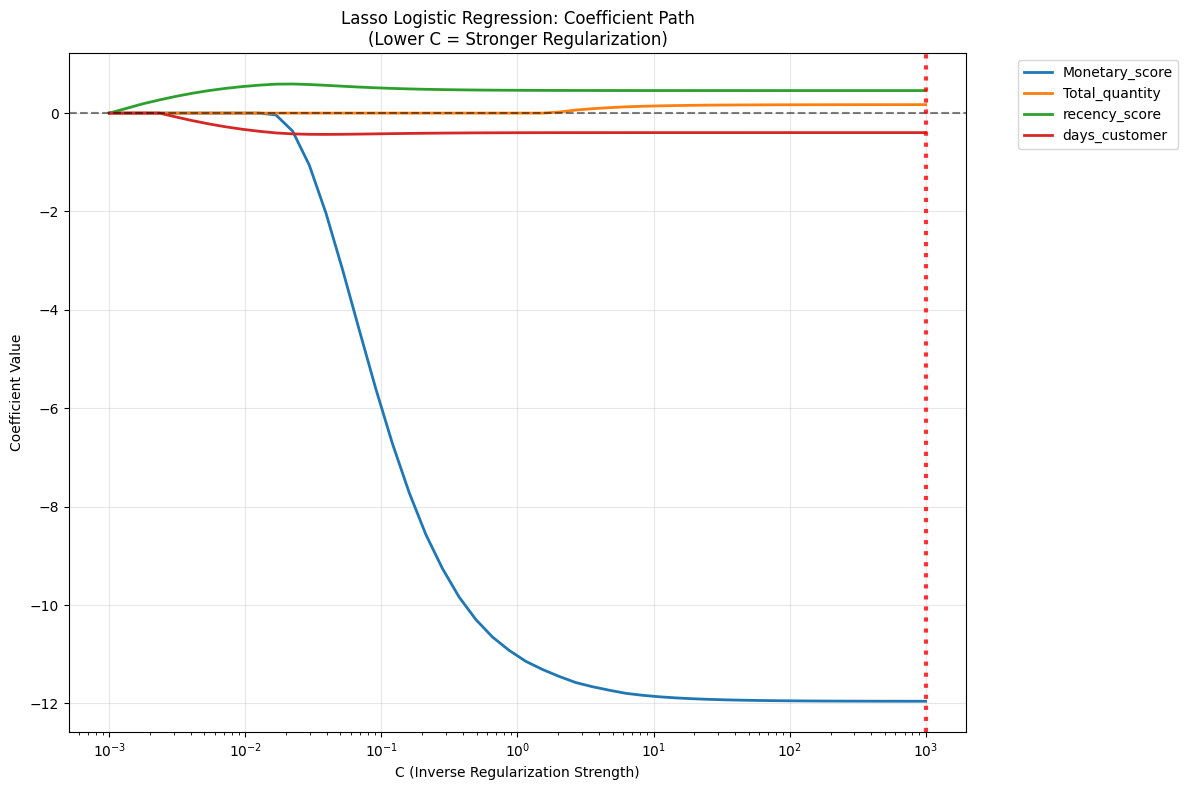

In [26]:
# Visualize Lasso Logistic Regression Coefficient Path

# Store coefficients for Lasso path visualization
lasso_coefficients = []

print("Computing Lasso coefficient path for visualization...")

# Lasso coefficient path - compute for visualization
for C in C_values:
    lasso_lr = LogisticRegression(
        penalty='l1', 
        C=C, 
        solver='liblinear',
        random_state=42,
        max_iter=2000
    )
    lasso_lr.fit(X_train_processed, y_train)
    lasso_coefficients.append(lasso_lr.coef_[0])

lasso_coefficients = np.array(lasso_coefficients)

# Plot Lasso coefficient path
plt.figure(figsize=(12, 8))

# Lasso coefficient path
for i, feature in enumerate(X_train.columns):
    plt.plot(C_values, lasso_coefficients[:, i], label=feature, linewidth=2)

plt.xscale('log')
plt.xlabel('C (Inverse Regularization Strength)')
plt.ylabel('Coefficient Value')
plt.title('Lasso Logistic Regression: Coefficient Path\n(Lower C = Stronger Regularization)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.axvline(x=lasso_grid.best_params_['classifier__C'], color='red', 
            linestyle=':', linewidth=3, alpha=0.8, label=f"Best C={lasso_grid.best_params_['classifier__C']}")
plt.tight_layout()
plt.show()

**Key insights:**
 
- **Lower C:** Stronger regularization --> coefficients shrink toward zero and can reach exactly zero
- **Lasso (L1):** Coefficients can shrink to exactly zero --> automatic feature selection
- **Most Important Features:** Features like `Recency_score` retains reasonable coefficient values even under strong regularization, indicating they are the most predictive for churn

### Elastic Net Logistic Regression

Elastic Net logistic regression combines both Ridge and Lasso approaches, using the same pipeline and hyperparameter tuning process. It uses both L1 and L2 regularization simultaneously, providing a balance between feature selection (L1) and coefficient shrinkage (L2).

**l1_ratio Parameter:**
- `l1_ratio = 0`: Pure Ridge regression (L2 only)
- `l1_ratio = 1`: Pure Lasso regression (L1 only)  
- `l1_ratio = 0.5`: Equal mix of L1 and L2 penalties

Let's apply the same systematic approach to see how Elastic Net balances Ridge and Lasso behaviors.

**Note**: Elatic Net uses `saga` as the solver since this is one of the few solvers that supports the combination of L1 and L2 penalties simultaneously.

In [27]:
# Elastic Net Logistic Regression  
print("ELASTIC NET LOGISTIC REGRESSION - HYPERPARAMETER TUNING")
print("=" * 60)

# Create Elastic Net logistic regression pipeline
elasticnet_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(penalty='elasticnet', solver='saga', random_state=42, max_iter=2000))
])

# Smaller parameter grid for Elastic Net (computational efficiency)
elasticnet_param_grid = {
    'classifier__C': [0.01, 0.1, 1.0, 10.0],  # Smaller grid for Elastic Net
    'classifier__l1_ratio': [0.1, 0.5, 0.9]   # L1 ratio: 0=Ridge, 1=Lasso
}

print(f"Elastic Net parameter combinations: {len(elasticnet_param_grid['classifier__C']) * len(elasticnet_param_grid['classifier__l1_ratio'])}")
print("(Smaller grid to manage computational complexity)")

# GridSearchCV with 5-fold cross-validation
elasticnet_grid = GridSearchCV(
    elasticnet_pipeline,
    elasticnet_param_grid,
    cv=5,
    scoring='roc_auc',
    return_train_score=True,
    n_jobs=-1
)

# Fit on training data
elasticnet_grid.fit(X_train, y_train)

# Evaluate on test set
y_pred_elastic = elasticnet_grid.predict(X_test)
y_pred_proba_elastic = elasticnet_grid.predict_proba(X_test)[:, 1]
test_auc_elastic = roc_auc_score(y_test, y_pred_proba_elastic)
test_accuracy_elastic = accuracy_score(y_test, y_pred_elastic)

print(f"Best parameters: {elasticnet_grid.best_params_}")
print(f"Best CV AUC: {elasticnet_grid.best_score_:.4f}")
print(f"Test AUC: {test_auc_elastic:.4f}")
print(f"Test Accuracy: {test_accuracy_elastic:.4f}")

# Get the best Elastic Net coefficients
best_elastic_coefs = elasticnet_grid.best_estimator_.named_steps['classifier'].coef_[0]
selected_features_elastic = X_train.columns[best_elastic_coefs != 0]
elastic_coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_elastic_coefs,
    'Selected': best_elastic_coefs != 0
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"\nElastic Net Feature Selection:")
print(f"C = {elasticnet_grid.best_params_['classifier__C']}, l1_ratio = {elasticnet_grid.best_params_['classifier__l1_ratio']}")
print(f"Selected {len(selected_features_elastic)} out of {len(X_train.columns)} features")
print(f"Selected features: {list(selected_features_elastic)}")
print(f"\nElastic Net Coefficients:")
print(elastic_coef_df.round(4))

ELASTIC NET LOGISTIC REGRESSION - HYPERPARAMETER TUNING
Elastic Net parameter combinations: 12
(Smaller grid to manage computational complexity)
Best parameters: {'classifier__C': 10.0, 'classifier__l1_ratio': 0.9}
Best CV AUC: 0.7703
Test AUC: 0.7487
Test Accuracy: 0.9625

Elastic Net Feature Selection:
C = 10.0, l1_ratio = 0.9
Selected 4 out of 4 features
Selected features: ['Monetary_score', 'Total_quantity', 'recency_score', 'days_customer']

Elastic Net Coefficients:
          Feature  Coefficient  Selected
0  Monetary_score      -3.6357      True
1  Total_quantity      -1.8742      True
2   recency_score       0.5395      True
3   days_customer      -0.4442      True


It is clear that Elastic Net balances out L1 and L2, but there is preference towards L1 (`l1_ratio=0.90`). This model also achieves the best performance overall, suggesting that a more nuanced combination of both penalties leads to better generalization and predictive power. 

Let's now plot the coefficient path as well. 

Computing Elastic Net coefficient path for visualization...
(Using reduced C range for computational efficiency)


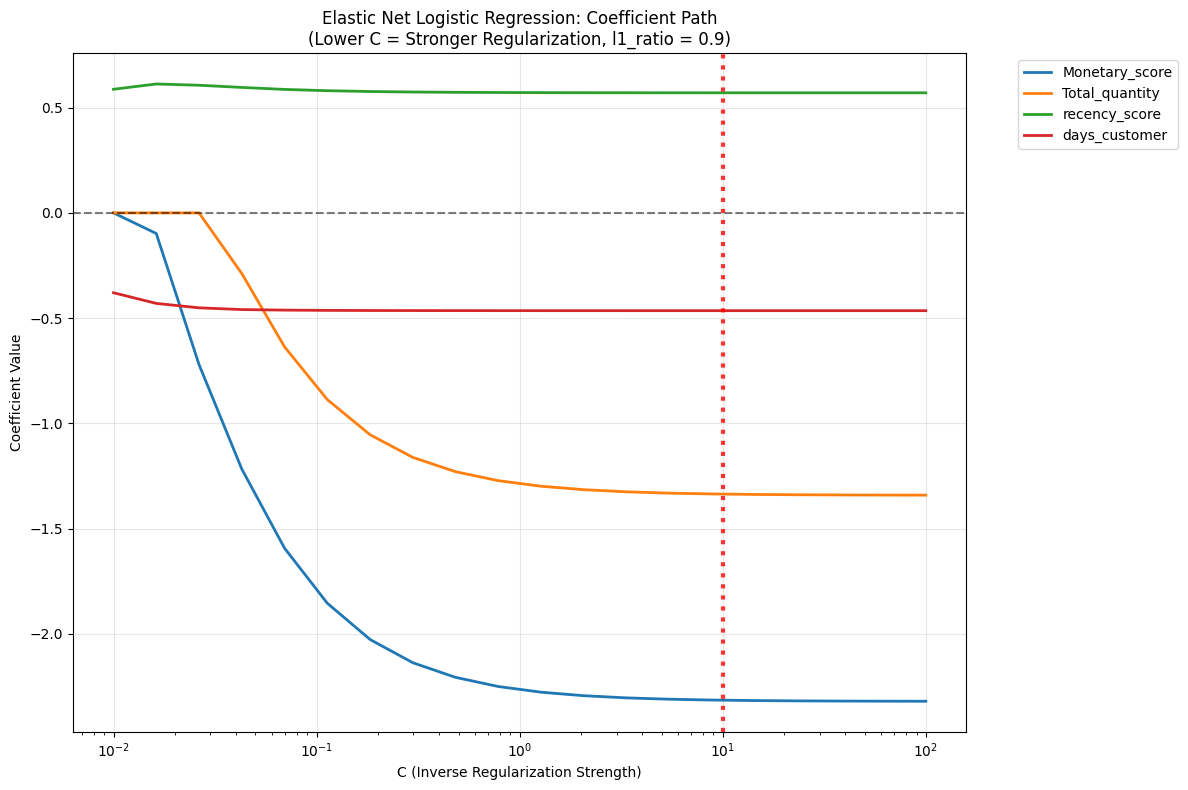

In [28]:
# Visualize Elastic Net Logistic Regression Coefficient Path

# Store coefficients for Elastic Net path visualization  
elastic_coefficients = []

print("Computing Elastic Net coefficient path for visualization...")
print("(Using reduced C range for computational efficiency)")

# Use the best l1_ratio found during hyperparameter tuning
best_l1_ratio = elasticnet_grid.best_params_['classifier__l1_ratio']

# Use a smaller range of C values for faster computation
C_values_reduced = np.logspace(-2, 2, 20)  # Reduced from 50 to 20 points

# Elastic Net coefficient path - reduced iterations for speed
for C in C_values_reduced:
    elastic_lr = LogisticRegression(
        penalty='elasticnet',
        C=C,
        l1_ratio=best_l1_ratio,
        solver='saga',
        random_state=42,
        max_iter=1000  # Reduced from 2000 to 1000
    )
    elastic_lr.fit(X_train_processed, y_train)
    elastic_coefficients.append(elastic_lr.coef_[0])

elastic_coefficients = np.array(elastic_coefficients)

# Plot Elastic Net coefficient path
plt.figure(figsize=(12, 8))

# Elastic Net coefficient path
for i, feature in enumerate(X_train.columns):
    plt.plot(C_values_reduced, elastic_coefficients[:, i], label=feature, linewidth=2)

plt.xscale('log')
plt.xlabel('C (Inverse Regularization Strength)')
plt.ylabel('Coefficient Value')
plt.title(f'Elastic Net Logistic Regression: Coefficient Path\n(Lower C = Stronger Regularization, l1_ratio = {best_l1_ratio})')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.axvline(x=elasticnet_grid.best_params_['classifier__C'], color='red', 
            linestyle=':', linewidth=3, alpha=0.8, label=f"Best C={elasticnet_grid.best_params_['classifier__C']}")
plt.tight_layout()
plt.show()

**Key insights:**
- Compared to **L1 regularization**, all coefficients remain active even for smaller values of C, and both `recency_score` and `days_customers` are never reduced to zero.
- Compared to **L2 regularization**, some coefficients are shrunken exactly to zero, introducing a feature selection effect.
- At the **current C value**, coefficients are only slightly penalized, meaning all variables remain active in the model.

### Logistic Regression Model Comparison

Now let's compare all three regularization methods side by side to understand their relative performance and coefficient behavior.

**Important Note on Coefficient Interpretation:**
In regularized logistic regression models (Ridge, Lasso, Elastic Net), **coefficients should NOT be interpreted the same way as standard logistic regression coefficients**. Due to the penalty terms:

- **Coefficients represent "relative importance" or "strength"** rather than precise log-odds changes
- **Magnitudes are shrunk** toward zero, making direct interpretation misleading
- **Use coefficients for feature ranking and selection**, not for quantifying exact effects
- **For precise interpretability**, use the selected features from regularized models to fit a final unregularized model

Let's examine the models through ROC curves and absolute coefficient values.

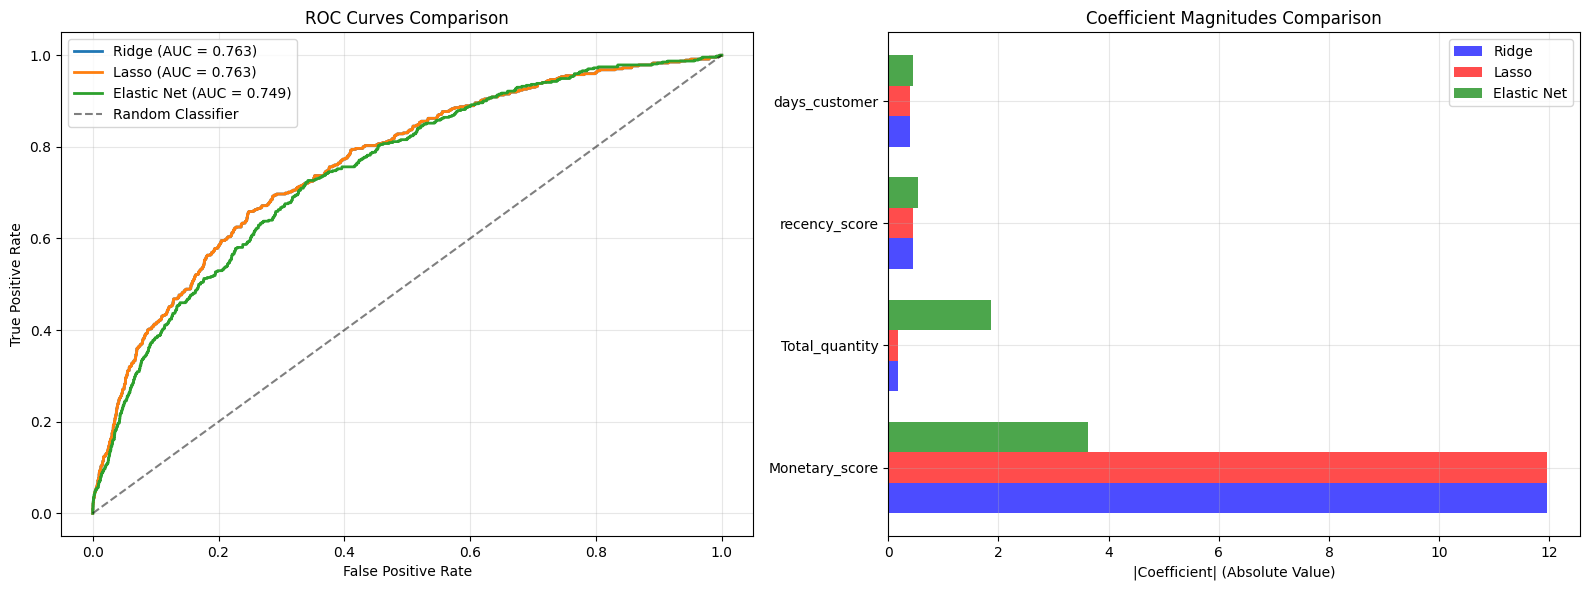

In [29]:
# Comprehensive Comparison: ROC Curves and Coefficients
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# =============================================================================
# 1. ROC CURVES COMPARISON
# =============================================================================
# Plot ROC curves for all three methods
fpr_ridge, tpr_ridge, _ = roc_curve(y_test, y_pred_proba_ridge)
fpr_lasso, tpr_lasso, _ = roc_curve(y_test, y_pred_proba_lasso)
fpr_elastic, tpr_elastic, _ = roc_curve(y_test, y_pred_proba_elastic)

axes[0].plot(fpr_ridge, tpr_ridge, linewidth=2, label=f'Ridge (AUC = {test_auc_ridge:.3f})')
axes[0].plot(fpr_lasso, tpr_lasso, linewidth=2, label=f'Lasso (AUC = {test_auc_lasso:.3f})')
axes[0].plot(fpr_elastic, tpr_elastic, linewidth=2, label=f'Elastic Net (AUC = {test_auc_elastic:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# =============================================================================
# 2. COEFFICIENT MAGNITUDES COMPARISON (HORIZONTAL BAR CHART)
# =============================================================================
# Compare coefficient magnitudes across all methods
coef_comparison = pd.DataFrame({
    'Feature': X_train.columns,
    'Ridge': np.abs(best_ridge_coefs),
    'Lasso': np.abs(best_lasso_coefs),
    'Elastic_Net': np.abs(best_elastic_coefs)
})

# Create horizontal bar chart
y_pos = np.arange(len(X_train.columns))
width = 0.25

# Plot bars for each method
axes[1].barh(y_pos - width, coef_comparison['Ridge'], width, 
             label='Ridge', alpha=0.7, color='blue')
axes[1].barh(y_pos, coef_comparison['Lasso'], width, 
             label='Lasso', alpha=0.7, color='red')
axes[1].barh(y_pos + width, coef_comparison['Elastic_Net'], width, 
             label='Elastic Net', alpha=0.7, color='green')

axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(X_train.columns)
axes[1].set_xlabel('|Coefficient| (Absolute Value)')
axes[1].set_title('Coefficient Magnitudes Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Conclusions

1. **Performance**: All three methods achieve very similar AUC scores, indicating that the choice between them may depend more on interpretability and feature selection needs than pure predictive performance.

2. **Feature Selection**: All features are always kept. The main reason is that there are only 4 variables and feature selection might not be needed. Only Lasso and Elastic Net perform true feature selection with higher values of lambda.

3. **Coefficient Interpretation**: 
   - **Magnitudes reflect relative importance**, not precise effect sizes
   - **Lasso coefficients** are most sparse (many zeros)
   - **Ridge coefficients** are most uniform (all non-zero but shrunk)
   - **Elastic Net coefficients** balance between the two approaches: it makes sure that some coefficients are zero and that the values of the coefficients are more uniform. 

4. **When to use**:
   - **Ridge:** When you want to keep all features but reduce overfitting
   - **Lasso:** When you need automatic feature selection and sparse models  
   - **Elastic Net:** When you want a balance between Ridge and Lasso, especially with correlated features.